# The limits of `numpy` arrays, and overcoming them

In this notebook, we will venture to the limits of `numpy` arrays. Our example dataset will be a large 3D image of a whole bird brain, courtesy of Simon Weiler. 

Biological and imaging details: serial-section two-photon tomography of a Eurasian blackcap, a migratory bird.

This is what a bird brain looks like:


Technical details: folder containing 2230 TIFF files of 40 MB each, totalling 91.GB. Each tiff file is a coronal slice.

In [1]:
from pathlib import Path
import numpy as np
import tifffile
import tracemalloc
from os import listdir
path = Path("/media/alessandro/T7/Irmak local/2p/CAP45/2/")

list_of_tiffs = [path / name for name in listdir(path)]


If we only care about visualing a coronal slice, this is easy. We can load it into a numpy array using the `tifffile` library. We add some helper code to help us track our memory usage, and confirm that we roughly use 40 MB of memory.

In [2]:
tracemalloc.start()
tifffile.imread(list_of_tiffs[0])
current, peak = tracemalloc.get_traced_memory()
print(f"current={current / 1e6:.1f} MB, peak={peak / 1e6:.1f} MB")
tracemalloc.stop()


current=0.0 MB, peak=64.7 MB


We hit our limits if we want to read a few hundred slices into a three-dimensional numpy array in memory, because this is 10-20 GB. This stops us from visualising a sagittal slice, because that would require us to load _all_ coronal slices into memory (even though we need just a small bit of each coronal slice).

In [3]:
tracemalloc.start()

number_of_images = 279
first_image = tifffile.imread(list_of_tiffs[0])
stack = np.empty((number_of_images, *first_image.shape), dtype=first_image.dtype)
stack[0] = first_image
for i, tiff_path in enumerate(list_of_tiffs[1:number_of_images], start=1):
    stack[i] = tifffile.imread(tiff_path)

current, peak = tracemalloc.get_traced_memory()
print(f"current={current / 1e6:.1f} MB, peak={peak / 1e6:.1f} MB")

tracemalloc.stop()
print(len(list_of_tiffs))
print(stack.shape)


current=18066.1 MB, peak=18131.0 MB
279
(279, 4941, 6529)


We can solve this problem nicely by using a "memmap", which allows us to tell `numpy` that not to allocate all that much memory by reassuring it that it will able to load the data from disk whenever we actually ask for it.

In [4]:

tracemalloc.start()

number_of_images = 279
first_image = tifffile.memmap(list_of_tiffs[0])
stack = np.empty((number_of_images, first_image.shape[0]), dtype=first_image.dtype)

print(type(first_image))
print(type(stack))
stack[0] = first_image[:, 2000]
for i, tiff_path in enumerate(list_of_tiffs[1:number_of_images], start=1):
    stack[i] = tifffile.memmap(tiff_path)[:, 2000]

current, peak = tracemalloc.get_traced_memory()
print(f"current={current / 1e6:.1f} MB, peak={peak / 1e6:.1f} MB")

tracemalloc.stop()
print(len(list_of_tiffs))
print(stack.shape)

<class 'numpy.memmap'>
<class 'numpy.ndarray'>


current=3.1 MB, peak=3.6 MB
279
(279, 4941)


Exercise: Make a plot of a transverse plane

This is very fast and memory efficient, so memory maps are a great solution, if the data is on disk and you are willing to do some coding acrobatics. Memory maps start to break down in two cases:

* your data doesn't live on disk (e.g. on the cloud)
* you need to process your data in parallel
* your data is compressed, or you want to compress it
* you want to keep track of your metadata

In [5]:
tracemalloc.start()

import dask.array as da

dask_arrays = []
for file in list_of_tiffs:
    slice = tifffile.memmap(file)
    dask_slice = da.from_array(slice, chunks=(100, 100))
    dask_arrays.append(dask_slice)

print(f"current={current / 1e6:.1f} MB, peak={peak / 1e6:.1f} MB")

tracemalloc.stop()


current=3.1 MB, peak=3.6 MB


In [6]:

tracemalloc.start()

dask_stack = da.stack(dask_arrays)
dask_stack.rechunk((100,100,100)) # expensive, but allows arbitrary re-slicing
current, peak = tracemalloc.get_traced_memory()
print(f"current={current / 1e6:.1f} MB, peak={peak / 1e6:.1f} MB")

tracemalloc.stop()


current=336.9 MB, peak=761.2 MB


In [7]:

tracemalloc.start()
print(dask_stack.shape)
coronal_slice = dask_stack[100,:,:]
sagittal_slice = dask_stack[:,2000,:]
horizontal_slice = dask_stack[:,:,3000]

current, peak = tracemalloc.get_traced_memory()
print(f"current={current / 1e6:.1f} MB, peak={peak / 1e6:.1f} MB")

tracemalloc.stop()
print(len(list_of_tiffs))
print(dask_stack.shape)


(279, 4941, 6529)


current=25.4 MB, peak=25.5 MB
279
(279, 4941, 6529)


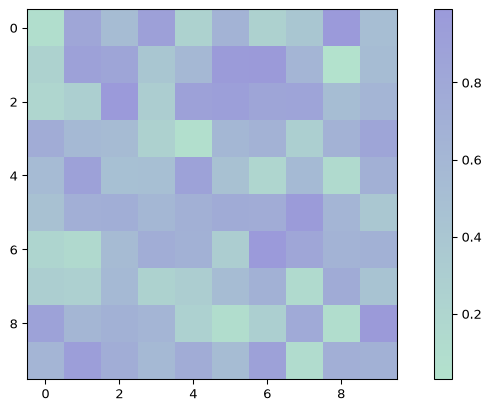

In [8]:
import matplotlib as mpl
from matplotlib.colors import LinearSegmentedColormap

mint = "#B3E2CD"
lavender = "#9B9ADA"

mint_lavender = LinearSegmentedColormap.from_list(
    "mint_lavender", [mint, lavender], N=256
)

# register so it can be called by name, e.g. cmap="mint_lavender"
mpl.colormaps.register(mint_lavender, name="mint_lavender", force=True)

import numpy as np
import matplotlib.pyplot as plt

data = np.random.rand(10, 10)
plt.imshow(data, cmap="mint_lavender")
plt.colorbar()
plt.show()